# Chapter 11: The Mathematics of Curiosity

A controller has two tools and limited opportunities to learn which one works more often. Always choosing the current favorite can waste the budget if early evidence was misleading. Always exploring can waste it even after the better tool is apparent. Curiosity is therefore a resource decision, not an unlimited appetite for information.

This notebook compares three finite policies against a constructed Bernoulli world. The true arm means are supplied to the simulator for scoring, while each policy chooses using its own observed successes. The chart measures pseudo-regret rather than presenting a lucky reward trace as proof of superiority. Change the arm ordering and seed before drawing a policy conclusion.

**Outcome:** Compare greedy, UCB, and Thompson choices in a declared stationary bandit.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

After n_a pulls and s_a successes, the empirical mean is s_a/n_a. Greedy choice selects the largest empirical mean. UCB adds an exploration bonus sqrt(2 ln t / n_a), where t is the number of completed pulls (Equation 11.2 with c equal to the square root of two), favoring arms whose uncertainty remains large relative to their evidence.

Thompson sampling uses a Beta(1,1) prior for each Bernoulli arm. Its posterior is Beta(s_a+1,n_a-s_a+1). Each round draws one candidate mean from each posterior and chooses the largest draw. A posterior sample is a decision device, not a certificate that an arm's true mean equals that sampled value.

Cumulative pseudo-regret is sum_t [max_a mu_a-mu_(A_t)]. It uses the simulator's known means and measures expected reward forgone by choices. Realized net reward sums observed zero/one outcomes minus pull costs. These differ because sampling noise can favor a worse arm in a finite run. Information value is another quantity: it prices how evidence improves a future decision, not the historical cumulative shortfall.

A separate one-pull information calculation uses the final Beta posterior. For each possible sampled arm, it averages the best posterior mean after a hypothetical success or failure, then subtracts the best current posterior mean. The net value also subtracts one pull cost. This is the Bayesian value of information for one later arm choice, not cumulative regret or a recommendation to continue the original budget.

## A calculation you can run

Supply arm means, a finite round budget, seed, and common pull cost. Each policy initializes untried arms once while budget remains, then uses its own decision rule. The simulator samples outcomes with a local seeded random generator, preserving offline reproducibility without modifying global random state.

The report gives pull counts, successes, pseudo-regret, and realized net reward for all policies. Curves show cumulative pseudo-regret by round. They are nondecreasing because each known-mean shortfall is nonnegative. Compare how frequently each policy visits the better arm, but do not rank policies statistically from a single seed. The changed case swaps means, testing whether early sampling and tie order affect the finite outcome.

The returned policy table also contains posterior means and gross/net one-pull information values. Inspect those separately from the regret chart: a policy can have accumulated regret even when an additional observation no longer changes its preferred action.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 11
inputs = {'means': [0.4, 0.7], 'rounds': 120, 'seed': 7, 'pull_cost': 0.05}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: constructed teaching example

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        2,
        118
      ],
      "successes": [
        1,
        89
      ],
      "cumulative_pseudo_regret": 0.6,
      "net_observed_reward": 84.0,
      "posterior_means": [
        0.5,
        0.75
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.05,
        -0.05
      ]
    },
    "ucb": {
      "counts": [
        31,
        89
      ],
      "successes": [
        16,
        67
      ],
      "cumulative_pseudo_regret": 9.3,
      "net_observed_reward": 77.0,
      "posterior_means": [
        0.5151515152,
        0.7472527473
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
 

In the default world, the optimal mean is 0.7 and the other arm's mean is 0.4. Every pull of the worse arm contributes 0.3 pseudo-regret; a pull of the best contributes zero. Therefore each policy's final regret must equal 0.3 times its worse-arm pull count, independent of realized successes.

The common cost 0.05 changes net observed reward but not pseudo-regret between arms, because it applies equally to every pull. The changed world reverses which arm is optimal. Counts and trajectories can change substantially even though the mean gap stays 0.3. That is a finite exploration diagnostic, not an empirical result about real tools.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


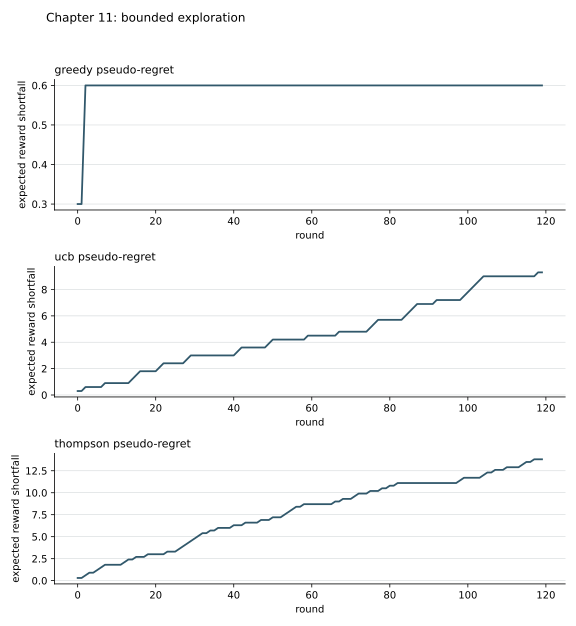

In [3]:
display(SVG(figure_svg(report)))

**Figure 11.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Stationarity is a central assumption. If an arm's success probability changes with time, task type, or another agent's behavior, the single mean no longer describes the process. A policy can then look stubborn because its accumulated evidence belongs to a different world.

The seeded comparison also does not provide a confidence interval for policy performance. Policies consume random numbers differently, especially Thompson sampling, so the same seed is a reproducibility device rather than perfectly matched outcome exposure. Use repeated independently declared seeds and a suitable comparison design for statistical claims.

A simulator oracle is not a deployed capability. Real logs usually do not reveal the true means needed for pseudo-regret. When those means are unavailable, report observed reward and an evaluation design instead of treating empirical averages as known truths.

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        110,
        10
      ],
      "successes": [
        81,
        7
      ],
      "cumulative_pseudo_regret": 3.0,
      "net_observed_reward": 82.0,
      "posterior_means": [
        0.7321428571,
        0.6666666667
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.05,
        -0.05
      ]
    },
    "ucb": {
      "counts": [
        95,
        25
      ],
      "successes": [
        71,
        11
      ],
      "cumulative_pseudo_regret": 7.5,
      "net_observed_reward": 76.0,
      "posterior_means": [
        0.7422680412,
        0.4444444444
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull

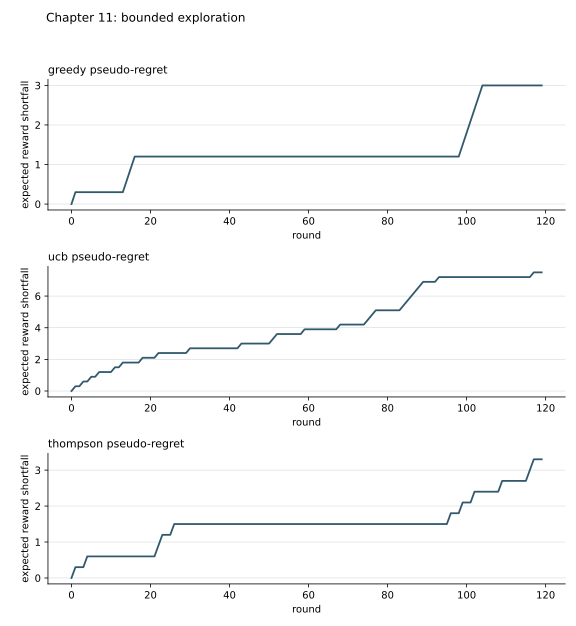

In [4]:
changed_inputs = {'means': [0.7, 0.4], 'rounds': 120, 'seed': 7, 'pull_cost': 0.05}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 11.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer problem has three arms, with gaps 0.6,0.3,0 relative to the best mean 0.8. Its pseudo-regret must equal 0.6 n_0+0.3 n_1. Check that identity against each returned count vector.

For a local exploration plan, specify budget, outcome predicate, arm availability, and the evidence supporting stationarity. Different tool costs require an extended objective rather than the equal-cost comparison here. Keep exploration expense separate from any proposed value-of-information calculation. If the real task asks whether one extra observation is worthwhile, use the belief and information method rather than relabeling regret.

In [5]:
transfer_inputs = {'means': [0.2, 0.5, 0.8], 'rounds': 90, 'seed': 19, 'pull_cost': 0.1}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: constructed transfer example

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        1,
        1,
        88
      ],
      "successes": [
        0,
        0,
        78
      ],
      "cumulative_pseudo_regret": 0.9,
      "net_observed_reward": 69.0,
      "posterior_means": [
        0.3333333333,
        0.3333333333,
        0.8777777778
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.1,
        -0.1,
        -0.1
      ]
    },
    "ucb": {
      "counts": [
        9,
        25,
        56
      ],
      "successes": [
        2,
        16,
        48
      ],
      "cumulative_pseudo_regret": 12.9,
      "net_observed_reward": 57.0,
      "posterior_means": [
        0.2727272727,
        0.6296296296,
        0.8448275862


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **means:** Arm success probabilities in [0,1], known only to this constructed simulator.
- **rounds:** Integer pull budget 1..10000.
- **seed:** Nonnegative integer random seed.
- **pull_cost:** Nonnegative common cost per pull.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch11.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        1,
        1,
        88
      ],
      "successes": [
        0,
        0,
        78
      ],
      "cumulative_pseudo_regret": 0.9,
      "net_observed_reward": 69.0,
      "posterior_means": [
        0.3333333333,
        0.3333333333,
        0.8777777778
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.1,
        -0.1,
        -0.1
      ]
    },
    "ucb": {
      "counts": [
        9,
        25,
        56
      ],
      "successes": [
        2,
        16,
        48
      ],
      "cumulative_pseudo_regret": 12.9,
      "net_observed_reward": 57.0,
      "posterior_means": [
        0.2727272727,
        0.6

## Questions

1. Express default regret through counts.

2. Does common pull cost change arm pseudo-regret?

3. Express transfer regret.

Answers: [separate solutions](../solutions/ch11.md). Try the calculation before opening them.

## Summary

Greedy, UCB, and posterior sampling make different finite exploration choices. The notebook separates known-mean pseudo-regret from realized net reward and records the seed and pull counts. Swapped means and a three-arm transfer case test the calculation. Its conclusions are conditional on stationary independent Bernoulli rewards. A favorable run does not demonstrate universal policy superiority, and known simulator means must not be mistaken for calibrated deployed-tool estimates.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-11-bounded-exploration`](../skills/maa-11-bounded-exploration/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 11.1

![Equation 11.1](../assets/math/0748ee3073daf997794a.svg)

Equation (11.1) measures the total payoff an agent gave up over its run by not always taking the action it would have taken had it known which was best.

Multiply the best action's mean payoff by the number of rounds, then subtract the average total the agent actually collected.

LaTeX source, preserved for inspection:

```latex
\operatorname{Reg}(T)=T\mu^{\star}-\operatorname{E}\!\left[\sum_{t=0}^{T-1}\mu_{a_t}\right].
\tag{11.1}
```

### Equation 11.2

![Equation 11.2](../assets/math/b25daa0c3c98ef2794a7.svg)

Equation (11.2) ranks actions by an optimistic estimate rather than a best guess, so an action stays in contention while it remains poorly understood.

Add to each action's average payoff a bonus that grows as the run lengthens and shrinks as that action is tried more often, then take the largest sum.

LaTeX source, preserved for inspection:

```latex
a_t=\arg\max_{a\in\mathcal{A}}\left(\hat\mu_a+c\sqrt{\frac{\ln t}{N_t(a)}}\right).
\tag{11.2}
```

### Equation 11.3

![Equation 11.3](../assets/math/638761b25c1352586c4f.svg)

Equation (11.3) measures how much a candidate observation would reduce uncertainty about the specific quantity a decision depends on, rather than about anything at all.

Subtract the uncertainty remaining about the decision-relevant quantity after the observation from the uncertainty before it.

LaTeX source, preserved for inspection:

```latex
\operatorname{Gain}(O)=I(Y;O)=H(Y)-H(Y\mid O).
\tag{11.3}
```

### Equation 11.4

![Equation 11.4](../assets/math/f9f2ae99c3d3c2206ea0.svg)

Equation (11.4) prices an observation by comparing the best the agent could do knowing it against the best it can do without it.

Take the average, over possible observations, of the best expected utility available after seeing each one, then subtract the best expected utility available now.

LaTeX source, preserved for inspection:

```latex
\operatorname{VOI}(O)=\operatorname{E}_{O}\!\left[\max_{a}\operatorname{EU}(a\mid O)\right]-\max_{a}\operatorname{EU}(a).
\tag{11.4}
```